In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("u.data", sep="\t", header=None)
data.columns = ["user_id", "movie_id", "rating", "timestamp"]

data.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
print(data.shape)
print(data.info())
print(data.describe())

(100000, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None
            user_id       movie_id         rating     timestamp
count  100000.00000  100000.000000  100000.000000  1.000000e+05
mean      462.48475     425.530130       3.529860  8.835289e+08
std       266.61442     330.798356       1.125674  5.343856e+06
min         1.00000       1.000000       1.000000  8.747247e+08
25%       254.00000     175.000000       3.000000  8.794487e+08
50%       447.00000     322.000000       4.000000  8.828269e+08
75%       682.00000     631.000000       4.000000  8.882600e+08
max       943.00000    1682.000000       5.000000  8.932866e+08


In [4]:
user_item_matrix = data.pivot_table(index="user_id", columns="movie_id", values="rating")
user_item_matrix.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
user_item_matrix_filled = user_item_matrix.fillna(0)

In [6]:
user_similarity = cosine_similarity(user_item_matrix_filled)
user_similarity_df = pd.DataFrame(user_similarity, 
                                 index=user_item_matrix.index, 
                                 columns=user_item_matrix.index)

In [7]:
def get_similar_users(user_id, n=10):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)
    return similar_users.iloc[1:n+1]

get_similar_users(1)

user_id
916    0.569066
864    0.547548
268    0.542077
92     0.540534
435    0.538665
457    0.538476
738    0.527031
429    0.525950
303    0.525718
276    0.524523
Name: 1, dtype: float64

In [8]:
def predict_ratings(user_id):
    similar_users = get_similar_users(user_id)
    user_ratings = user_item_matrix_filled.loc[user_id]

    pred_ratings = pd.Series(dtype=float)

    for movie in user_item_matrix.columns:
        if user_ratings[movie] == 0:
            sim_scores = similar_users
            movie_ratings = user_item_matrix_filled.loc[sim_scores.index, movie]

            weighted_sum = np.dot(sim_scores, movie_ratings)
            sum_of_weights = sim_scores.sum()

            if sum_of_weights != 0:
                pred_ratings[movie] = weighted_sum / sum_of_weights
            else:
                pred_ratings[movie] = 0

    return pred_ratings

predict_ratings(1).head()

273    3.105382
274    0.987725
275    1.298682
276    3.104567
277    0.684245
dtype: float64

In [9]:
movies = pd.read_csv("u.item", sep="|", encoding="latin-1", header=None)
movies = movies[[0, 1]]  
movies.columns = ["movie_id", "movie_name"]

movies.head()

,movie_id,movie_name
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [10]:
movie_dict = dict(zip(movies.movie_id, movies.movie_name))

In [13]:
def recommend_movies(user_id, n=5):
    predicted_ratings = predict_ratings(user_id)
    
    already_watched = user_item_matrix.loc[user_id].dropna().index
    
    recommendations = predicted_ratings.drop(already_watched, errors='ignore')
    
    recommendations.index = recommendations.index.map(movie_dict)
    return recommendations.sort_values(ascending=False).head(n)

print(recommend_movies(1))


Schindler's List (1993)                                                        4.088954
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)    3.904887
Stand by Me (1986)                                                             3.696039
E.T. the Extra-Terrestrial (1982)                                              3.691327
Batman (1989)                                                                  3.678409
dtype: float64


In [17]:
actual = []
predicted = []

for user in user_item_matrix.columns[:10]:  
    
    pred = predict_ratings(user)
    
    actual_ratings = user_item_matrix[user].dropna()   
    
    for movie in actual_ratings.index:
        if movie in pred:
            actual.append(actual_ratings[movie])
            predicted.append(pred[movie])

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 3.5453995684462085
MAE: 3.3352591824494424


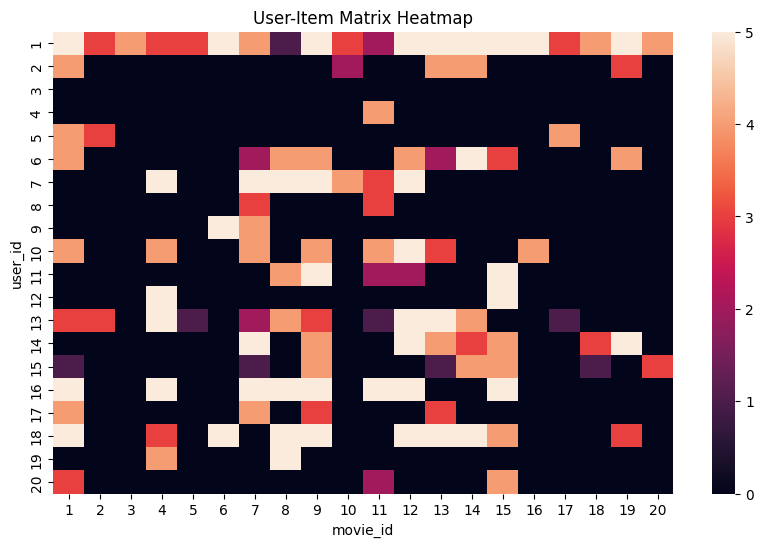

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(user_item_matrix_filled.iloc[:20, :20])
plt.title("User-Item Matrix Heatmap")
plt.show()

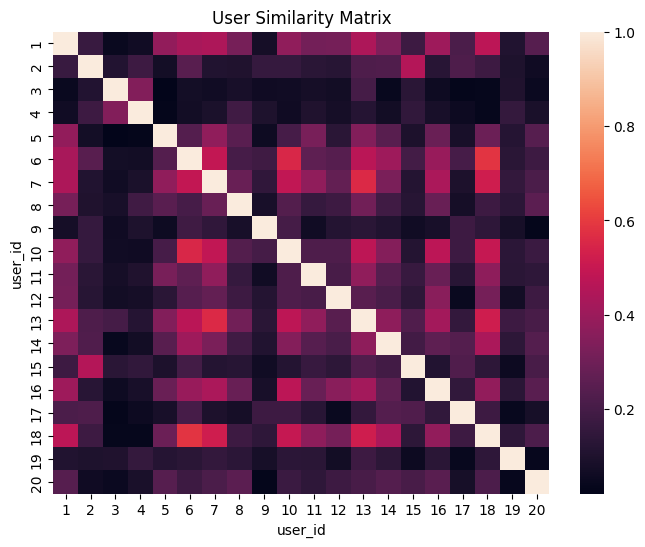

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20])
plt.title("User Similarity Matrix")
plt.show()

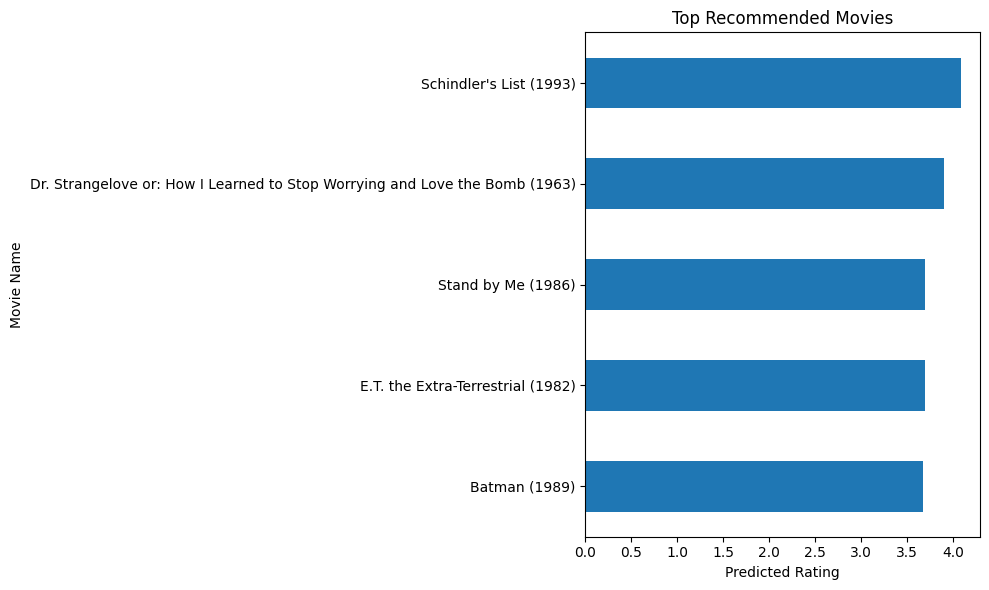

In [ ]:
plt.figure(figsize=(10,6))
top_rec.sort_values().plot(kind='barh')

plt.title("Top Recommended Movies")
plt.xlabel("Predicted Rating")
plt.ylabel("Movie Name")

plt.tight_layout()
plt.show()

